In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("D:\\bajaj-fraud-fairness\\backend\\data\\insurance_claims.csv")
df.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,2,YES,71610,6510,13020,52080,Saab,92x,2004,Y
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,0,?,5070,780,780,3510,Mercedes,E400,2007,Y
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,3,NO,34650,7700,3850,23100,Dodge,RAM,2007,N
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,2,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,1,NO,6500,1300,650,4550,Accura,RSX,2009,N


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 39 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   str    
 4   policy_state                 1000 non-null   str    
 5   policy_csl                   1000 non-null   str    
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   str    
 11  insured_education_level      1000 non-null   str    
 12  insured_occupation           1000 non-null   str    
 13  insured_hobbies              1

In [5]:
df["fraud_reported"].value_counts(normalize=True)   # class imbalance

fraud_reported
N    0.753
Y    0.247
Name: proportion, dtype: float64

In [6]:
for col in ["insured_zip", "incident_location", "auto_model", "auto_make"]:
    print(col, df[col].nunique())
    

insured_zip 995
incident_location 1000
auto_model 39
auto_make 14


Are there missing values, and what do they mean?

In [7]:
print(df.isna().sum()[df.isna().sum() > 0])
print((df == "?").sum()[(df == "?").sum() > 0])
raw = pd.read_csv("../data/insurance_claims.csv", keep_default_na=False)
print(raw["authorities_contacted"].value_counts())

authorities_contacted    91
dtype: int64
collision_type             178
property_damage            360
police_report_available    343
dtype: int64
authorities_contacted
Police       292
Fire         223
Other        198
Ambulance    196
None          91
Name: count, dtype: int64


Does fraud rate differ between groups?

In [8]:
d = df.assign(fraud=df["fraud_reported"].eq("Y"))
for col in ["incident_severity", "policy_state", "incident_state", "insured_sex", "collision_type"]:
    print(d.groupby(col)["fraud"].mean().round(3), "\n")

incident_severity
Major Damage      0.605
Minor Damage      0.107
Total Loss        0.129
Trivial Damage    0.067
Name: fraud, dtype: float64 

policy_state
IL    0.228
IN    0.255
OH    0.259
Name: fraud, dtype: float64 

incident_state
NC    0.309
NY    0.221
OH    0.435
PA    0.267
SC    0.294
VA    0.227
WV    0.180
Name: fraud, dtype: float64 

insured_sex
FEMALE    0.235
MALE      0.261
Name: fraud, dtype: float64 

collision_type
?                  0.090
Front Collision    0.276
Rear Collision     0.312
Side Collision     0.254
Name: fraud, dtype: float64 



In [10]:
df["incident_state"].value_counts()

incident_state
NY    262
SC    248
WV    217
VA    110
NC    110
PA     30
OH     23
Name: count, dtype: int64

Do the dates contain any fraud signal?

In [9]:

df["days_since_bind"] = (pd.to_datetime(df["incident_date"]) - pd.to_datetime(df["policy_bind_date"])).dt.days
df.groupby("fraud_reported")["days_since_bind"].describe()

,count,mean,std,min,25%,50%,75%,max
fraud_reported,,,,,,,,
N,753.0,4737.710491,2692.065623,-20.0,2450.0,4734.0,7067.0,9172.0
Y,247.0,4743.497976,2674.616719,82.0,2525.0,4638.0,7103.0,9124.0


In [20]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from xgboost import XGBClassifier

# 1. Load (keep "None" as a real category) and mark "?" as its own label
raw = pd.read_csv("../data/insurance_claims.csv", keep_default_na=False)
raw = raw.replace("?", "Unknown")
y = raw["fraud_reported"].eq("Y").astype(int)

# 2. Lock away 20% as a test set. Don't touch raw_test / y_test until the very end.
raw, raw_test, y, y_test = train_test_split(
    raw, y, test_size=0.2, stratify=y, random_state=42
)
raw = raw.reset_index(drop=True)
y = y.reset_index(drop=True)

# 3. Build the three feature sets (training rows only)
base_drop = ["policy_number", "policy_bind_date", "insured_zip",
             "incident_date", "incident_location", "fraud_reported"]

X_base = pd.get_dummies(raw.drop(columns=base_drop + ["auto_model"]), dtype=int)
X_with_model = pd.get_dummies(raw.drop(columns=base_drop), dtype=int)
X_ratio = X_base.copy()
X_ratio["claim_to_premium_ratio"] = raw["total_claim_amount"] / raw["policy_annual_premium"]

# 4. Scoring function: 5-fold cross-validation
def evaluate(X, y):
    model = XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.05,
                          subsample=0.8, colsample_bytree=0.8,
                          eval_metric="logloss", random_state=42)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    res = cross_validate(model, X, y, cv=cv, scoring=["roc_auc", "average_precision"])
    return round(res["test_roc_auc"].mean(), 3), round(res["test_average_precision"].mean(), 3)

# 5. Compare the three versions
print("training rows:", len(raw), "| fraud rate:", round(y.mean(), 3))
print("baseline         (roc_auc, avg_precision):", evaluate(X_base, y))
print("with auto_model  (roc_auc, avg_precision):", evaluate(X_with_model, y))
print("with ratio       (roc_auc, avg_precision):", evaluate(X_ratio, y))

training rows: 800 | fraud rate: 0.248
baseline         (roc_auc, avg_precision): (np.float64(0.859), np.float64(0.676))
with auto_model  (roc_auc, avg_precision): (np.float64(0.86), np.float64(0.688))
with ratio       (roc_auc, avg_precision): (np.float64(0.858), np.float64(0.668))


Is the total claim just the three parts added up?

In [21]:
parts = raw["injury_claim"] + raw["property_claim"] + raw["vehicle_claim"]
print("share of rows where total == sum of parts:", (parts == raw["total_claim_amount"]).mean())
raw.describe().T[["min", "50%", "max"]]

share of rows where total == sum of parts: 1.0


,min,50%,max
months_as_customer,0.00,202.00,479.00
age,20.00,38.50,64.00
policy_number,100804.00,533940.50,999435.00
policy_deductable,500.00,1000.00,2000.00
policy_annual_premium,433.33,1265.78,2047.59
umbrella_limit,-1000000.00,0.00,10000000.00
insured_zip,430104.00,466704.50,620962.00
capital-gains,0.00,0.00,100500.00
capital-loss,-111100.00,-21200.00,0.00
incident_hour_of_the_day,0.00,12.00,23.00


Which is better for the model: the total, the three parts, or all four?

In [22]:
X_total_only = X_base.drop(columns=["injury_claim", "property_claim", "vehicle_claim"])
X_parts_only = X_base.drop(columns=["total_claim_amount"])
print("all four columns:", evaluate(X_base, y))
print("total only      :", evaluate(X_total_only, y))
print("parts only      :", evaluate(X_parts_only, y))

all four columns: (np.float64(0.859), np.float64(0.676))
total only      : (np.float64(0.865), np.float64(0.69))
parts only      : (np.float64(0.853), np.float64(0.669))


Does the model need age and sex to do well?

In [23]:
sens = [c for c in X_base.columns if c == "age" or c.startswith("insured_sex_")]
X_no_sens = X_base.drop(columns=sens)
print("with age + sex   :", evaluate(X_base, y))
print("without age + sex:", evaluate(X_no_sens, y))

with age + sex   : (np.float64(0.859), np.float64(0.676))
without age + sex: (np.float64(0.864), np.float64(0.682))


Does giving fraud cases more weight help?

In [24]:
def evaluate_with(X, y, **params):
    settings = dict(n_estimators=200, max_depth=3, learning_rate=0.05,
                    subsample=0.8, colsample_bytree=0.8,
                    eval_metric="logloss", random_state=42)
    settings.update(params)
    model = XGBClassifier(**settings)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    res = cross_validate(model, X, y, cv=cv, scoring=["roc_auc", "average_precision"])
    return round(res["test_roc_auc"].mean(), 3), round(res["test_average_precision"].mean(), 3)

spw = (y == 0).sum() / (y == 1).sum()
print("no weighting:", evaluate_with(X_base, y))
print("weighted    :", evaluate_with(X_base, y, scale_pos_weight=spw))

no weighting: (np.float64(0.859), np.float64(0.676))
weighted    : (np.float64(0.857), np.float64(0.664))


Which model settings work best?

In [25]:
results = []
for depth in [2, 3, 4]:
    for lr in [0.03, 0.05, 0.1]:
        for n in [100, 200, 300]:
            auc, ap = evaluate_with(X_base, y, max_depth=depth, learning_rate=lr, n_estimators=n)
            results.append((depth, lr, n, auc, ap))

pd.DataFrame(results, columns=["max_depth", "learning_rate", "n_estimators",
                               "roc_auc", "avg_precision"]).sort_values(
    "avg_precision", ascending=False).head(5)

,max_depth,learning_rate,n_estimators,roc_auc,avg_precision
9,3,0.03,100,0.871,0.722
3,2,0.05,100,0.869,0.707
0,2,0.03,100,0.871,0.701
10,3,0.03,200,0.863,0.698
18,4,0.03,100,0.856,0.696


At what score should a claim be flagged?

In [26]:
from sklearn.model_selection import cross_val_predict

model = XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.05,
                      subsample=0.8, colsample_bytree=0.8,
                      eval_metric="logloss", random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
proba = cross_val_predict(model, X_base, y, cv=cv, method="predict_proba")[:, 1]
yv = y.to_numpy()

for t in [0.2, 0.3, 0.4, 0.5, 0.6]:
    pred = proba >= t
    tp = (pred & (yv == 1)).sum()
    print(f"threshold {t}: flagged {pred.sum()}, "
          f"precision {tp / max(pred.sum(), 1):.2f}, recall {tp / (yv == 1).sum():.2f}")

threshold 0.2: flagged 267, precision 0.66, recall 0.88
threshold 0.3: flagged 250, precision 0.65, recall 0.82
threshold 0.4: flagged 229, precision 0.66, recall 0.76
threshold 0.5: flagged 199, precision 0.67, recall 0.68
threshold 0.6: flagged 140, precision 0.70, recall 0.49


build the final features

In [27]:
final_drop = base_drop + ["auto_model", "injury_claim", "property_claim",
                          "vehicle_claim", "age", "insured_sex"]
X_final = raw.drop(columns=final_drop).copy()

print("negative umbrella_limit rows:", (X_final["umbrella_limit"] < 0).sum())
X_final["umbrella_limit"] = X_final["umbrella_limit"].clip(lower=0)

X_final = pd.get_dummies(X_final, dtype=int)
print("final feature count:", X_final.shape[1])
print("default settings:", evaluate(X_final, y))

negative umbrella_limit rows: 1
final feature count: 116
default settings: (np.float64(0.865), np.float64(0.7))


repeat the settings search on the final features

In [28]:
results = []
for depth in [2, 3, 4]:
    for lr in [0.03, 0.05, 0.1]:
        for n in [100, 200, 300]:
            auc, ap = evaluate_with(X_final, y, max_depth=depth, learning_rate=lr, n_estimators=n)
            results.append((depth, lr, n, auc, ap))

res_final = pd.DataFrame(results, columns=["max_depth", "learning_rate", "n_estimators",
                                           "roc_auc", "avg_precision"]
                         ).sort_values("avg_precision", ascending=False)
res_final.head(5)

,max_depth,learning_rate,n_estimators,roc_auc,avg_precision
18,4,0.03,100,0.866,0.710
9,3,0.03,100,0.869,0.705
19,4,0.03,200,0.863,0.702
13,3,0.05,200,0.865,0.700
12,3,0.05,100,0.863,0.699


choose the flagging threshold for the best settings

In [29]:
from sklearn.model_selection import cross_val_predict

best = res_final.iloc[0]
print("using:", dict(best[["max_depth", "learning_rate", "n_estimators"]]))

model = XGBClassifier(n_estimators=int(best["n_estimators"]),
                      max_depth=int(best["max_depth"]),
                      learning_rate=float(best["learning_rate"]),
                      subsample=0.8, colsample_bytree=0.8,
                      eval_metric="logloss", random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
proba = cross_val_predict(model, X_final, y, cv=cv, method="predict_proba")[:, 1]
yv = y.to_numpy()

for t in [0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.5]:
    pred = proba >= t
    tp = (pred & (yv == 1)).sum()
    print(f"threshold {t}: flagged {pred.sum()} of {len(yv)}, "
          f"precision {tp / max(pred.sum(), 1):.2f}, recall {tp / (yv == 1).sum():.2f}")

using: {'max_depth': np.float64(4.0), 'learning_rate': np.float64(0.03), 'n_estimators': np.float64(100.0)}
threshold 0.15: flagged 271 of 800, precision 0.65, recall 0.89
threshold 0.2: flagged 271 of 800, precision 0.65, recall 0.89
threshold 0.25: flagged 271 of 800, precision 0.65, recall 0.89
threshold 0.3: flagged 267 of 800, precision 0.65, recall 0.88
threshold 0.35: flagged 261 of 800, precision 0.65, recall 0.85
threshold 0.4: flagged 249 of 800, precision 0.65, recall 0.82
threshold 0.5: flagged 203 of 800, precision 0.67, recall 0.69


freeze the settings and redo the threshold table

In [30]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from xgboost import XGBClassifier

final_params = dict(n_estimators=100, max_depth=3, learning_rate=0.03,
                    subsample=0.8, colsample_bytree=0.8,
                    eval_metric="logloss", random_state=42)

model = XGBClassifier(**final_params)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
proba = cross_val_predict(model, X_final, y, cv=cv, method="predict_proba")[:, 1]
yv = y.to_numpy()

for t in [0.25, 0.3, 0.35, 0.4, 0.45, 0.5]:
    pred = proba >= t
    tp = (pred & (yv == 1)).sum()
    print(f"threshold {t}: flagged {pred.sum()} of {len(yv)} ({pred.mean():.0%}), "
          f"precision {tp / max(pred.sum(), 1):.2f}, recall {tp / (yv == 1).sum():.2f}")

threshold 0.25: flagged 271 of 800 (34%), precision 0.65, recall 0.89
threshold 0.3: flagged 270 of 800 (34%), precision 0.65, recall 0.89
threshold 0.35: flagged 266 of 800 (33%), precision 0.65, recall 0.87
threshold 0.4: flagged 256 of 800 (32%), precision 0.66, recall 0.85
threshold 0.45: flagged 240 of 800 (30%), precision 0.65, recall 0.78
threshold 0.5: flagged 213 of 800 (27%), precision 0.66, recall 0.71


does the model beat a one-line rule?

In [31]:
rule = (raw["incident_severity"] == "Major Damage").to_numpy()
tp = (rule & (yv == 1)).sum()
print(f"rule 'Major Damage': flagged {rule.sum()} of {len(yv)} ({rule.mean():.0%}), "
      f"precision {tp / rule.sum():.2f}, recall {tp / (yv == 1).sum():.2f}")

rule 'Major Damage': flagged 219 of 800 (27%), precision 0.60, recall 0.66


score the locked test set, once

In [32]:
from sklearn.metrics import roc_auc_score, average_precision_score

THRESHOLD = 0.40

X_test_final = raw_test.drop(columns=final_drop).copy()
X_test_final["umbrella_limit"] = X_test_final["umbrella_limit"].clip(lower=0)
X_test_final = pd.get_dummies(X_test_final, dtype=int)
X_test_final = X_test_final.reindex(columns=X_final.columns, fill_value=0)

final_model = XGBClassifier(**final_params).fit(X_final, y)
test_proba = final_model.predict_proba(X_test_final)[:, 1]
yt = y_test.to_numpy()

pred = test_proba >= THRESHOLD
tp = (pred & (yt == 1)).sum()
print("test rows:", len(yt), "| fraud cases:", yt.sum())
print("ROC-AUC:", round(roc_auc_score(yt, test_proba), 3))
print("Avg precision:", round(average_precision_score(yt, test_proba), 3))
print(f"flagged {pred.sum()} ({pred.mean():.0%}), "
      f"precision {tp / max(pred.sum(), 1):.2f}, recall {tp / yt.sum():.2f}")

test rows: 200 | fraud cases: 49
ROC-AUC: 0.809
Avg precision: 0.532
flagged 66 (33%), precision 0.64, recall 0.86


SHAP

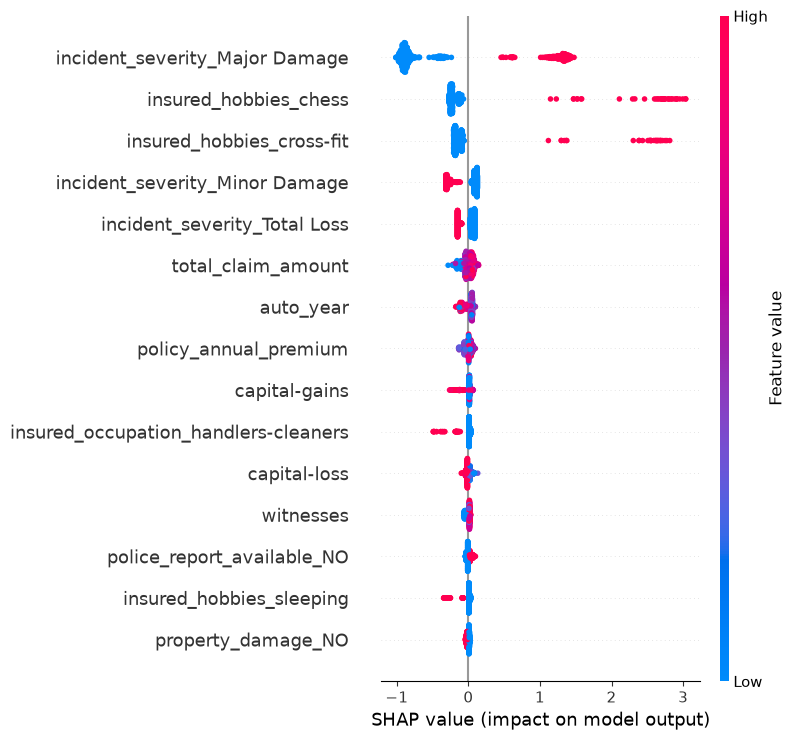

incident_severity_Major Damage          0.956
insured_hobbies_chess                   0.313
insured_hobbies_cross-fit               0.237
incident_severity_Minor Damage          0.161
incident_severity_Total Loss            0.082
total_claim_amount                      0.059
auto_year                               0.054
policy_annual_premium                   0.034
capital-gains                           0.028
insured_occupation_handlers-cleaners    0.028
dtype: float32
fraud probability for this claim: 0.046


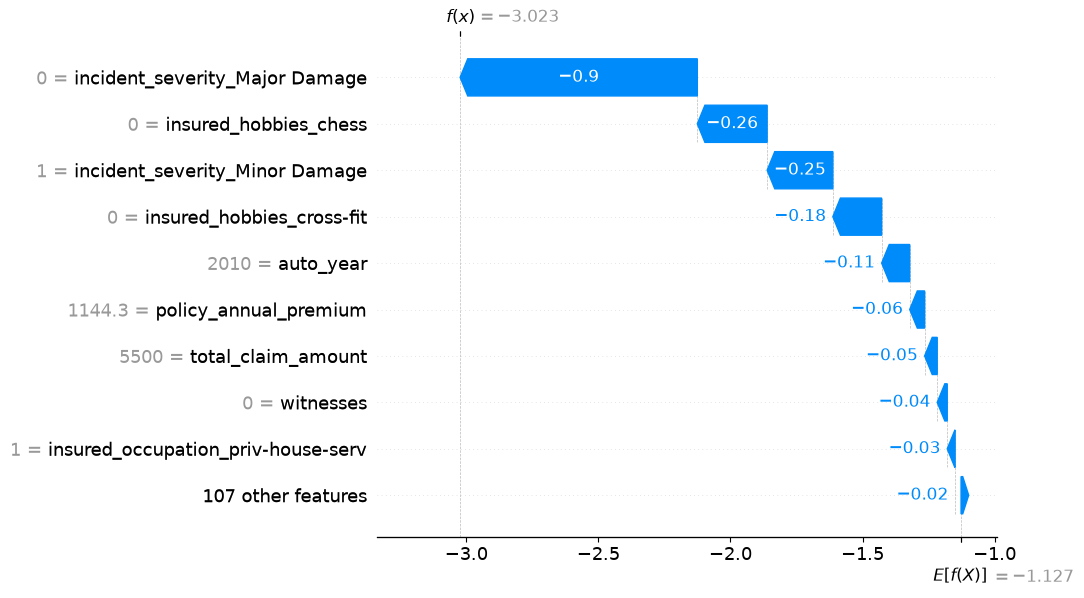

In [33]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(final_model)

# 1. Global view: which features matter overall (training rows)
shap_values = explainer.shap_values(X_final)
shap.summary_plot(shap_values, X_final, max_display=15)

# 2. Same information as a plain table
import numpy as np
importance = pd.Series(np.abs(shap_values).mean(axis=0), index=X_final.columns)
print(importance.sort_values(ascending=False).head(10).round(3))

# 3. One claim explained: the first test claim
sv = explainer(X_test_final)
print("fraud probability for this claim:", round(float(test_proba[0]), 3))
shap.plots.waterfall(sv[0], max_display=10)

the fairness audit

In [34]:
# 1. Honest scores for all 1000 claims: out-of-fold for training rows, test scores for the rest
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_proba = cross_val_predict(XGBClassifier(**final_params), X_final, y,
                              cv=cv, method="predict_proba")[:, 1]

cols = ["age", "insured_sex", "policy_state", "incident_state"]
audit = pd.concat([
    raw[cols].assign(fraud=y.to_numpy(), score=oof_proba),
    raw_test[cols].assign(fraud=y_test.to_numpy(), score=test_proba),
], ignore_index=True)

audit["flagged"] = audit["score"] >= THRESHOLD
audit["age_bracket"] = pd.cut(audit["age"], bins=[0, 29, 39, 49, 100],
                              labels=["<30", "30-39", "40-49", "50+"])

# 2. Report per group (groups under 30 claims are shown but left out of the ratio)
def group_report(col, min_n=30):
    g = audit.groupby(col, observed=True).agg(
        n=("flagged", "size"), flag_rate=("flagged", "mean"), fraud_rate=("fraud", "mean"))
    g["catch_rate"] = audit[audit.fraud == 1].groupby(col, observed=True)["flagged"].mean()
    g["false_flag_rate"] = audit[audit.fraud == 0].groupby(col, observed=True)["flagged"].mean()
    big = g[g.n >= min_n]
    di_flag = big.flag_rate.min() / big.flag_rate.max()
    di_pass = (1 - big.flag_rate).min() / (1 - big.flag_rate).max()
    print(f"\n=== {col} ===")
    print(g.round(3))
    print(f"flag-rate ratio (lowest/highest): {di_flag:.2f} | "
          f"not-flagged ratio (the 80% rule): {di_pass:.2f}")

for c in ["policy_state", "insured_sex", "age_bracket", "incident_state"]:
    group_report(c)


=== policy_state ===
                n  flag_rate  fraud_rate  catch_rate  false_flag_rate
policy_state                                                         
IL            338      0.328       0.228       0.896            0.161
IN            310      0.310       0.255       0.848            0.126
OH            352      0.327       0.259       0.813            0.157
flag-rate ratio (lowest/highest): 0.94 | not-flagged ratio (the 80% rule): 0.97

=== insured_sex ===
               n  flag_rate  fraud_rate  catch_rate  false_flag_rate
insured_sex                                                         
FEMALE       537      0.307       0.235       0.833            0.146
MALE         463      0.339       0.261       0.868            0.152
flag-rate ratio (lowest/highest): 0.91 | not-flagged ratio (the 80% rule): 0.95

=== age_bracket ===
               n  flag_rate  fraud_rate  catch_rate  false_flag_rate
age_bracket                                                         
<30         

In [35]:
print(raw[["age", "months_as_customer"]].corr().round(2))

fp = dict(n_estimators=100, max_depth=3, learning_rate=0.03)
hobby = [c for c in X_final.columns if c.startswith("insured_hobbies_")]
occup = [c for c in X_final.columns if c.startswith("insured_occupation_")]

print("current final           :", evaluate_with(X_final, y, **fp))
print("without hobbies         :", evaluate_with(X_final.drop(columns=hobby), y, **fp))
print("without hobbies + occup :", evaluate_with(X_final.drop(columns=hobby + occup), y, **fp))
print("without months_as_cust  :", evaluate_with(X_final.drop(columns=["months_as_customer"]), y, **fp))

                     age  months_as_customer
age                 1.00                0.92
months_as_customer  0.92                1.00
current final           : (np.float64(0.869), np.float64(0.705))
without hobbies         : (np.float64(0.731), np.float64(0.51))
without hobbies + occup : (np.float64(0.732), np.float64(0.503))
without months_as_cust  : (np.float64(0.872), np.float64(0.713))


In [36]:
fp = dict(n_estimators=100, max_depth=3, learning_rate=0.03)
occup = [c for c in X_final.columns if c.startswith("insured_occupation_")]
no_months = X_final.drop(columns=["months_as_customer"])

print("without months              :", evaluate_with(no_months, y, **fp))
print("without months + occupation :", evaluate_with(no_months.drop(columns=occup), y, **fp))

without months              : (np.float64(0.872), np.float64(0.713))
without months + occupation : (np.float64(0.872), np.float64(0.717))


In [37]:
DROP_EXTRA = ["months_as_customer"]
DROP_OCCUPATION = False   # set True if Cell J says occupation can go

def build_features(df):
    X = df.drop(columns=final_drop + DROP_EXTRA).copy()
    X["umbrella_limit"] = X["umbrella_limit"].clip(lower=0)
    if DROP_OCCUPATION:
        X = X.drop(columns=["insured_occupation"])
    return pd.get_dummies(X, dtype=int)

X_train2 = build_features(raw)
X_test2 = build_features(raw_test).reindex(columns=X_train2.columns, fill_value=0)

# honest scores for training rows (out-of-fold) and the model for the test rows
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof2 = cross_val_predict(XGBClassifier(**final_params), X_train2, y,
                         cv=cv, method="predict_proba")[:, 1]
final_model2 = XGBClassifier(**final_params).fit(X_train2, y)
test2 = final_model2.predict_proba(X_test2)[:, 1]

# does 0.40 still behave the same? (a check, not a new tuning round)
yv = y.to_numpy()
pred = oof2 >= THRESHOLD
tp = (pred & (yv == 1)).sum()
print(f"CV at {THRESHOLD}: flagged {pred.mean():.0%}, precision {tp / pred.sum():.2f}, "
      f"recall {tp / yv.sum():.2f}")

# second and last look at the locked test set
yt = y_test.to_numpy()
pt = test2 >= THRESHOLD
tpt = (pt & (yt == 1)).sum()
print("TEST ROC-AUC:", round(roc_auc_score(yt, test2), 3),
      "| avg precision:", round(average_precision_score(yt, test2), 3))
print(f"TEST flagged {pt.mean():.0%}, precision {tpt / pt.sum():.2f}, recall {tpt / yt.sum():.2f}")

# fairness audit, with groups under 100 claims left out of the ratios
audit = pd.concat([
    raw[cols].assign(fraud=yv, score=oof2),
    raw_test[cols].assign(fraud=yt, score=test2),
], ignore_index=True)
audit["flagged"] = audit["score"] >= THRESHOLD
audit["age_bracket"] = pd.cut(audit["age"], bins=[0, 29, 39, 49, 100],
                              labels=["<30", "30-39", "40-49", "50+"])

for c in ["policy_state", "insured_sex", "age_bracket", "incident_state"]:
    group_report(c, min_n=100)

CV at 0.4: flagged 32%, precision 0.65, recall 0.85
TEST ROC-AUC: 0.829 | avg precision: 0.576
TEST flagged 33%, precision 0.64, recall 0.86

=== policy_state ===
                n  flag_rate  fraud_rate  catch_rate  false_flag_rate
policy_state                                                         
IL            338      0.325       0.228       0.883            0.161
IN            310      0.313       0.255       0.848            0.130
OH            352      0.330       0.259       0.824            0.157
flag-rate ratio (lowest/highest): 0.95 | not-flagged ratio (the 80% rule): 0.98

=== insured_sex ===
               n  flag_rate  fraud_rate  catch_rate  false_flag_rate
insured_sex                                                         
FEMALE       537      0.307       0.235       0.833            0.146
MALE         463      0.341       0.261       0.868            0.155
flag-rate ratio (lowest/highest): 0.90 | not-flagged ratio (the 80% rule): 0.95

=== age_bracket ===
         

find out why 50+ gets flagged more

In [38]:
d = raw.assign(
    fraud=yv,
    age_bracket=pd.cut(raw["age"], bins=[0, 29, 39, 49, 100],
                       labels=["<30", "30-39", "40-49", "50+"]))
d["is50"] = d["age_bracket"].eq("50+")
d["major_damage"] = d["incident_severity"].eq("Major Damage")
d["chess_or_crossfit"] = d["insured_hobbies"].isin(["chess", "cross-fit"])

print("ALL claims:")
print(d.groupby("is50")[["major_damage", "chess_or_crossfit", "fraud"]].mean().round(3))
print("\nHONEST claims only:")
print(d[d["fraud"] == 0].groupby("is50")[["major_damage", "chess_or_crossfit"]].mean().round(3))

ALL claims:
       major_damage  chess_or_crossfit  fraud
is50                                         
False         0.263              0.079   0.24
True          0.350              0.110   0.30

HONEST claims only:
       major_damage  chess_or_crossfit
is50                                  
False         0.139              0.015
True          0.200              0.014
